# VR Workrooms — Affective NLP Analysis
### Meta Reality Labs · User Feedback Pipeline

**What this notebook does:** Takes user feedback from three sources and maps how people emotionally experience each proposed VR environment, so the 3D arts team gets structured actionable findings instead of raw survey data.

| Source | N | Participant type | Weight |
|---|---|---|---|
| `survey_responses.csv` | 108 | Customer | 0.40 |
| `interview_segments.csv` | 20 | Customer | 0.45 |
| `sticky_notes.csv` | 60 | Internal colleague | 0.15 |

> **All charts use matplotlib — fully static, renders on GitHub.**

---
## 1. Install & imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import subprocess, sys
for pkg in ['vaderSentiment','spacy','scikit-learn','pandas','numpy',
            'transformers','torch','wordcloud','matplotlib','seaborn','Pillow']:
    subprocess.check_call([sys.executable,'-m','pip','install',pkg,'--quiet'])
subprocess.check_call([sys.executable,'-m','spacy','download','en_core_web_sm','--quiet'])
print('All packages ready.')

All packages ready.


In [3]:
import pandas as pd, numpy as np, re, warnings, math, random
warnings.filterwarnings('ignore')

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import spacy
from transformers import pipeline as hf_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from wordcloud import WordCloud, STOPWORDS

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from IPython.display import display, Image

pd.set_option('display.max_colwidth', 120)
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Imports OK.')

Imports OK.


---
## 2. Load data & clean text

Each source needs slightly different cleaning:
- **Surveys** — well-formed sentences, just strip whitespace
- **Interviews** — conversational, remove filler words
- **Sticky notes** — very short, informal; lowercase + fix abbreviations + add punctuation

In [4]:
PATH = '/content/drive/MyDrive/Data Science/7. NLP - META/'
surveys    = pd.read_csv(PATH + 'survey_responses.csv')
interviews = pd.read_csv(PATH + 'interview_segments.csv')
stickies   = pd.read_csv(PATH + 'sticky_notes.csv')
print(f'Surveys {len(surveys)} | Interviews {len(interviews)} | Stickies {len(stickies)}')
surveys.head(2)

Surveys 108 | Interviews 20 | Stickies 60


,response_id,environment,customer_industry,customer_job_title,company_size,remote_work_frequency,feel_text,occasion_text,change_text,rating_comfort,rating_focus,rating_professionalism,rating_creativity
0,S001,executive_boardroom,financial_services,Senior Account Manager,large,fully_remote,The dark wood panelling and leather immediately signalled that this is a serious space. I felt like I needed to sit ...,This is exactly where I would host a quarterly business review or a client onboarding session for a major account. N...,The ceiling feels slightly low which adds to the sense of pressure. A window with a view would help without losing t...,3,4,5,2
1,S002,executive_boardroom,consulting,Principal Consultant,large,hybrid,It feels professional in a way that video calls never do. The materials are communicating something to the other per...,Client presentations. Strategy sessions. Anything where I need the environment to back me up.,Could be slightly less dark. The gravitas is right but the darkness tips into claustrophobic after a long session.,4,4,5,2


In [5]:
def clean_survey(t):
    return re.sub(r'\s+', ' ', str(t).strip())

def clean_interview(t):
    t = re.sub(r'\b(you know|kind of|sort of|um|uh)\b', '', str(t), flags=re.I)
    return re.sub(r'\s+', ' ', t).strip()

def clean_sticky(t):
    t = str(t).strip().lower().replace('1on1','one on one').replace('1-on-1','one on one')
    t = t[0].upper() + t[1:] if t else t
    return t if t and t[-1] in '.!?' else t + '.'

surveys['text_clean']    = surveys['feel_text'].apply(clean_survey)
surveys['text_occasion'] = surveys['occasion_text'].apply(clean_survey)
interviews['text_clean'] = interviews['segment_text'].apply(clean_interview)
stickies['text_clean']   = stickies['note_text'].apply(clean_sticky)
print('Cleaning done.')

Cleaning done.


---
## 3. Build unified corpus

All three sources merged with source labels and confidence weights:
interviews `0.45` > surveys `0.40` > sticky notes `0.15`

In [6]:
def make_rows(df, id_col, grp_col, source, weight, ptype):
    r = df[[id_col, 'environment', grp_col, 'text_clean']].copy()
    r.columns = ['doc_id', 'environment', 'group', 'text']
    r[['source', 'weight', 'participant_type']] = source, weight, ptype
    return r

corpus = pd.concat([
    make_rows(surveys,    'response_id',  'customer_industry', 'survey',    0.40, 'customer'),
    make_rows(interviews, 'interview_id', 'customer_industry', 'interview', 0.45, 'customer'),
    make_rows(stickies,   'note_id',      'role_group',        'sticky',    0.15, 'internal_colleague'),
], ignore_index=True)
print(f'Total docs: {len(corpus)}')
print(corpus.groupby(['source', 'participant_type']).size().to_string())

Total docs: 188
source     participant_type  
interview  customer               20
sticky     internal_colleague     60
survey     customer              108


---
## 4. Sentiment analysis (VADER)

VADER compound score: **−1 = very negative → +1 = very positive**.  
Domain lexicon extended with VR/workplace terms before scoring.

In [7]:
analyser = SentimentIntensityAnalyzer()
analyser.lexicon.update({
    'gravitas':2.0, 'immersive':2.5, 'grounded':1.8, 'grounding':1.8,
    'refreshing':2.5, 'purposeful':2.0, 'presence':2.0, 'cinematic':2.0,
    'restorative':2.2, 'authoritative':1.5, 'oppressive':-2.5,
    'claustrophobic':-2.5, 'alienating':-2.8, 'sterile':-1.5,
    'clinical':-1.5, 'inhuman':-2.0, 'disconnected':-3.0, 'floating':-1.5,
})

def get_sentiment(t): return analyser.polarity_scores(str(t))['compound']
def sentiment_label(s): return 'positive' if s>=0.05 else ('negative' if s<=-0.05 else 'neutral')

corpus['sentiment_score'] = corpus['text'].apply(get_sentiment)
corpus['sentiment_label'] = corpus['sentiment_score'].apply(sentiment_label)
print(corpus['sentiment_label'].value_counts().to_string())

sentiment_label
positive    147
negative     24
neutral      17


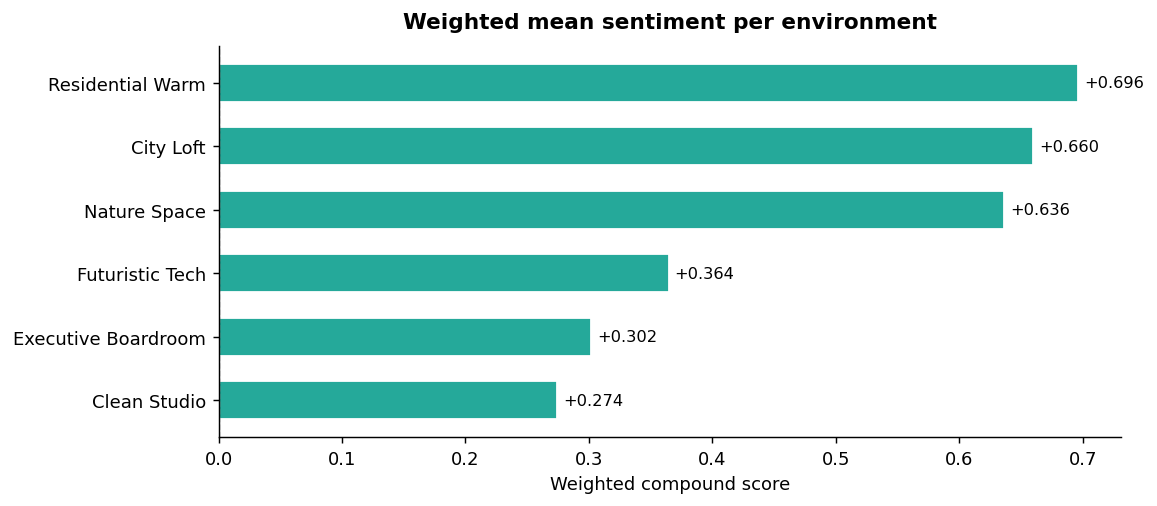

In [8]:
ENV_LABELS = {
    'executive_boardroom': 'Executive Boardroom',
    'nature_space':        'Nature Space',
    'clean_studio':        'Clean Studio',
    'residential_warm':    'Residential Warm',
    'futuristic_tech':     'Futuristic Tech',
    'city_loft':           'City Loft',
}
ENV_COLOURS = {
    'Executive Boardroom': '#6b5c8a',
    'Nature Space':        '#3d9e62',
    'Clean Studio':        '#888888',
    'Residential Warm':    '#c8821a',
    'Futuristic Tech':     '#2563ae',
    'City Loft':           '#b56030',
}
corpus['env_label'] = corpus['environment'].map(ENV_LABELS)

sent_by_env = (
    corpus.groupby('env_label')
    .apply(lambda g: np.average(g['sentiment_score'], weights=g['weight']))
    .reset_index(name='weighted_sentiment')
    .sort_values('weighted_sentiment')
)

fig, ax = plt.subplots(figsize=(9, 4))
colours = ['#e74c3c' if v < 0 else '#25a99a' for v in sent_by_env['weighted_sentiment']]
bars = ax.barh(sent_by_env['env_label'], sent_by_env['weighted_sentiment'],
               color=colours, height=0.6, edgecolor='white')
ax.axvline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, sent_by_env['weighted_sentiment']):
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_xlabel('Weighted compound score')
ax.set_title('Weighted mean sentiment per environment', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig_sent_mean.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_sent_mean.png'))

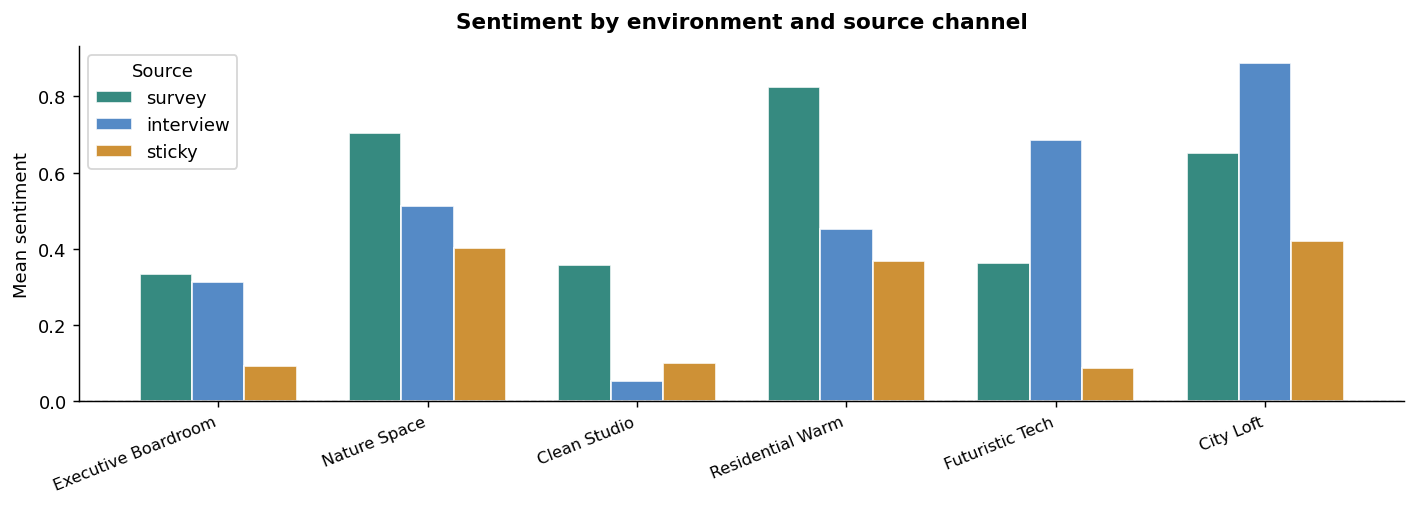

In [9]:
# Sentiment by environment AND source channel
sent_source = corpus.groupby(['env_label','source'])['sentiment_score'].mean().reset_index()
SOURCE_C    = {'survey':'#1a7a6e', 'interview':'#3d7abf', 'sticky':'#c8821a'}
sources     = ['survey', 'interview', 'sticky']
envs        = list(ENV_LABELS.values())
x, width    = np.arange(len(envs)), 0.25

fig, ax = plt.subplots(figsize=(11, 4))
for i, src in enumerate(sources):
    d    = sent_source[sent_source['source']==src].set_index('env_label')['sentiment_score']
    vals = [d.get(e, 0) for e in envs]
    ax.bar(x + i*width, vals, width, label=src, color=SOURCE_C[src], alpha=0.88, edgecolor='white')
ax.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
ax.set_xticks(x + width)
ax.set_xticklabels(envs, rotation=22, ha='right', fontsize=9)
ax.set_ylabel('Mean sentiment')
ax.set_title('Sentiment by environment and source channel', fontweight='bold', pad=10)
ax.legend(title='Source')
plt.tight_layout()
plt.savefig('fig_sent_source.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_sent_source.png'))

### Sentiment shape — violin plot
The bar chart shows the **mean**. The violin shows the full **distribution shape** — whether responses cluster tightly or split between positive and negative poles.

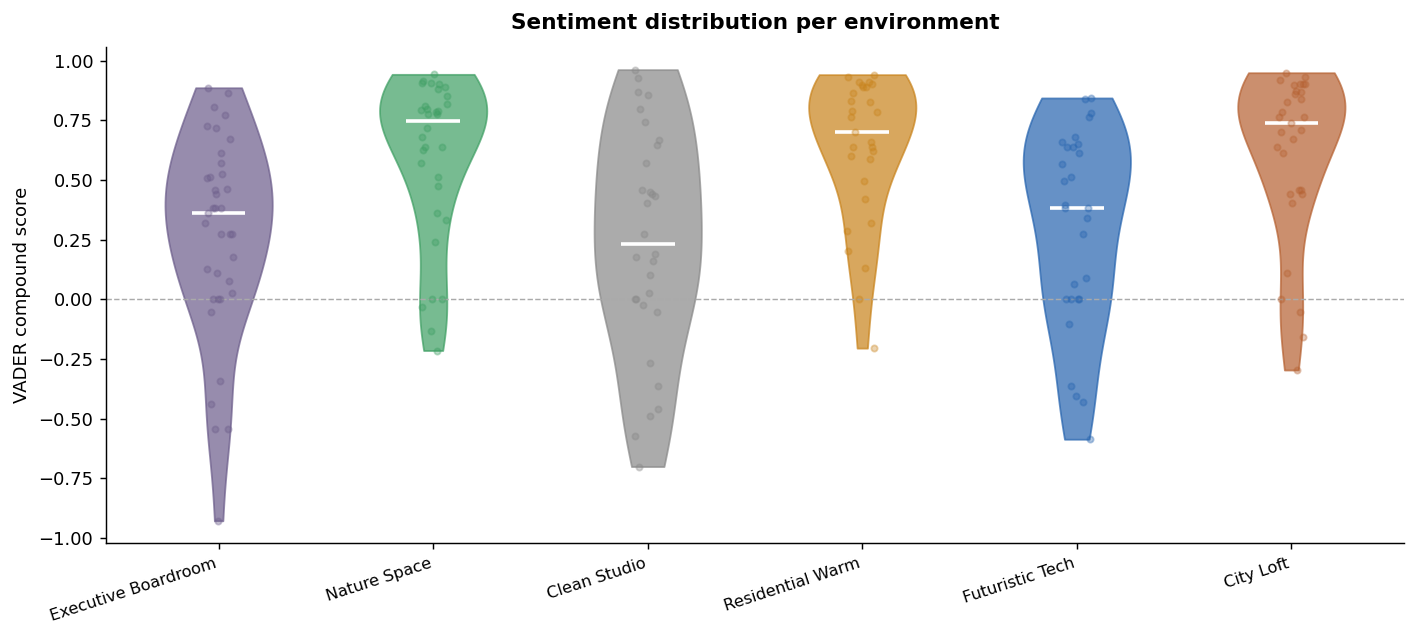

In [10]:
plot_data = [(env, corpus[corpus['env_label']==env]['sentiment_score'].values)
             for env in ENV_LABELS.values()]

fig, ax = plt.subplots(figsize=(11, 5))
vp = ax.violinplot([d for _, d in plot_data], positions=range(len(plot_data)),
                   showmedians=True, showextrema=False)
for body, (env, _) in zip(vp['bodies'], plot_data):
    c = ENV_COLOURS[env]
    body.set_facecolor(c); body.set_alpha(0.70); body.set_edgecolor(c)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
for i, (env, d) in enumerate(plot_data):
    jitter = np.random.uniform(-0.07, 0.07, len(d))
    ax.scatter(np.full(len(d), i) + jitter, d,
               s=12, alpha=0.35, color=ENV_COLOURS[env], zorder=3)
ax.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
ax.set_xticks(range(len(plot_data)))
ax.set_xticklabels([e for e, _ in plot_data], rotation=18, ha='right', fontsize=9)
ax.set_ylabel('VADER compound score')
ax.set_title('Sentiment distribution per environment', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig_violin.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_violin.png'))

---
## 5. Emotion scoring (NRC lexicon — self-contained)

Maps words to 8 emotion dimensions: joy, trust, fear, surprise, sadness, disgust, anger, anticipation.  
Score per doc = proportion of matched emotion words in each category.

In [11]:
NRC_LEXICON = {
    'happy':['joy','positive'],'happiness':['joy','positive'],'joyful':['joy','positive'],
    'delight':['joy','positive'],'pleasure':['joy','positive'],'pleasant':['joy','positive'],
    'enjoy':['joy','positive'],'enjoyable':['joy','positive'],'love':['joy','positive','trust'],
    'lovely':['joy','positive'],'wonderful':['joy','positive'],'beautiful':['joy','positive'],
    'excellent':['joy','positive'],'great':['joy','positive'],'fantastic':['joy','positive'],
    'refreshing':['joy','positive'],'refreshed':['joy','positive'],
    'calm':['joy','positive','trust'],'calming':['joy','positive','trust'],
    'settled':['joy','positive','trust'],'grounded':['joy','positive','trust'],
    'inspired':['joy','positive','anticipation'],'inspiring':['joy','positive','anticipation'],
    'energised':['joy','positive','anticipation'],'cinematic':['joy','positive'],
    'restorative':['joy','positive','trust'],'extraordinary':['joy','surprise','positive'],
    'remarkable':['joy','surprise','positive'],'impressive':['joy','surprise','positive'],
    'genuine':['joy','trust','positive'],'genuinely':['joy','positive'],
    'trust':['trust','positive'],'credible':['trust','positive'],'professional':['trust','positive'],
    'authority':['trust','positive'],'authoritative':['trust','positive'],'serious':['trust'],
    'gravitas':['trust','positive'],'sophisticated':['trust','positive'],'quality':['trust','positive'],
    'reliable':['trust','positive'],'safe':['trust','positive'],'secure':['trust','positive'],
    'purposeful':['trust','positive'],'functional':['trust','positive'],'effective':['trust','positive'],
    'warm':['trust','positive','joy'],'warmth':['trust','positive','joy'],'presence':['trust','positive'],
    'focused':['trust','positive'],'focus':['trust','positive'],
    'comfortable':['trust','positive','joy'],'comfort':['trust','positive','joy'],
    'welcoming':['trust','positive','joy'],'inviting':['trust','positive','joy'],
    'immersive':['trust','positive'],'honest':['trust','positive'],'grounding':['trust','positive'],
    'fear':['fear','negative'],'afraid':['fear','negative'],'anxiety':['fear','negative'],
    'anxious':['fear','negative'],'uneasy':['fear','negative'],'worried':['fear','negative'],
    'tense':['fear','negative'],'tension':['fear','negative'],'pressure':['fear','negative'],
    'stressed':['fear','negative'],'overwhelming':['fear','negative'],
    'claustrophobic':['fear','negative'],'oppressive':['fear','negative'],
    'intimidating':['fear','negative'],'uncomfortable':['fear','negative'],
    'distracted':['fear','negative'],'distracting':['fear','negative'],
    'exposed':['fear','negative'],'isolated':['fear','negative','sadness'],
    'surprise':['surprise'],'surprised':['surprise','positive'],'unexpected':['surprise'],
    'striking':['surprise','positive'],'notable':['surprise','positive'],
    'sad':['sadness','negative'],'lonely':['sadness','negative'],'empty':['sadness','negative'],
    'cold':['sadness','negative'],'sterile':['sadness','negative'],'clinical':['sadness','negative'],
    'detached':['sadness','negative'],'alienated':['sadness','negative'],
    'alienating':['sadness','negative'],'disconnected':['sadness','negative'],
    'inhuman':['sadness','negative'],'depressing':['sadness','negative'],'dull':['sadness','negative'],
    'fatigued':['sadness','negative'],'fatigue':['sadness','negative'],'depleted':['sadness','negative'],
    'awful':['disgust','negative'],'terrible':['disgust','negative'],'horrible':['disgust','negative'],
    'unpleasant':['disgust','negative'],'confusing':['disgust','negative'],
    'anger':['anger','negative'],'angry':['anger','negative'],'frustrated':['anger','negative'],
    'frustrating':['anger','negative'],'frustration':['anger','negative'],'annoying':['anger','negative'],
    'anticipation':['anticipation','positive'],'exciting':['anticipation','positive','joy'],
    'excited':['anticipation','positive','joy'],'innovative':['anticipation','positive'],
    'creative':['anticipation','positive'],'expansive':['anticipation','positive'],
    'ambitious':['anticipation','positive'],'dynamic':['anticipation','positive'],
    'motivating':['anticipation','positive'],'energetic':['anticipation','positive'],
}
NRC_EMOTIONS = ['joy','trust','fear','surprise','sadness','disgust','anger','anticipation']

def get_nrc_scores(text):
    words  = re.findall(r'[a-z]+', str(text).lower())
    counts = {e: 0 for e in NRC_EMOTIONS}
    for w in words:
        for e in NRC_LEXICON.get(w, []):
            if e in counts: counts[e] += 1
    total = sum(counts.values())
    return {e: round(counts[e]/total, 4) if total else 0.0 for e in NRC_EMOTIONS}

print({k:v for k,v in get_nrc_scores('calm trust warm fear anxiety excitement').items() if v>0})

{'joy': 0.2857, 'trust': 0.4286, 'fear': 0.2857}


In [12]:
print('Scoring emotions...')
corpus = pd.concat(
    [corpus.reset_index(drop=True),
     pd.DataFrame(corpus['text'].apply(get_nrc_scores).tolist())],
    axis=1
)
coverage = (corpus[NRC_EMOTIONS].sum(axis=1) > 0).mean()
print(f'Done. {coverage:.0%} of docs matched at least one emotion word.')
corpus[['doc_id','environment','source'] + NRC_EMOTIONS].head(5)

Scoring emotions...
Done. 79% of docs matched at least one emotion word.


,doc_id,environment,source,joy,trust,fear,surprise,sadness,disgust,anger,anticipation
0,S001,executive_boardroom,survey,0.00,1.00,0.0,0.0,0.0,0.0,0.0,0.0
1,S002,executive_boardroom,survey,0.00,1.00,0.0,0.0,0.0,0.0,0.0,0.0
2,S003,executive_boardroom,survey,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0
3,S004,executive_boardroom,survey,0.25,0.75,0.0,0.0,0.0,0.0,0.0,0.0
4,S005,executive_boardroom,survey,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0


### ☁️ Vocabulary fingerprints — word clouds
Each environment's dominant vocabulary. Size = frequency after stopword removal.

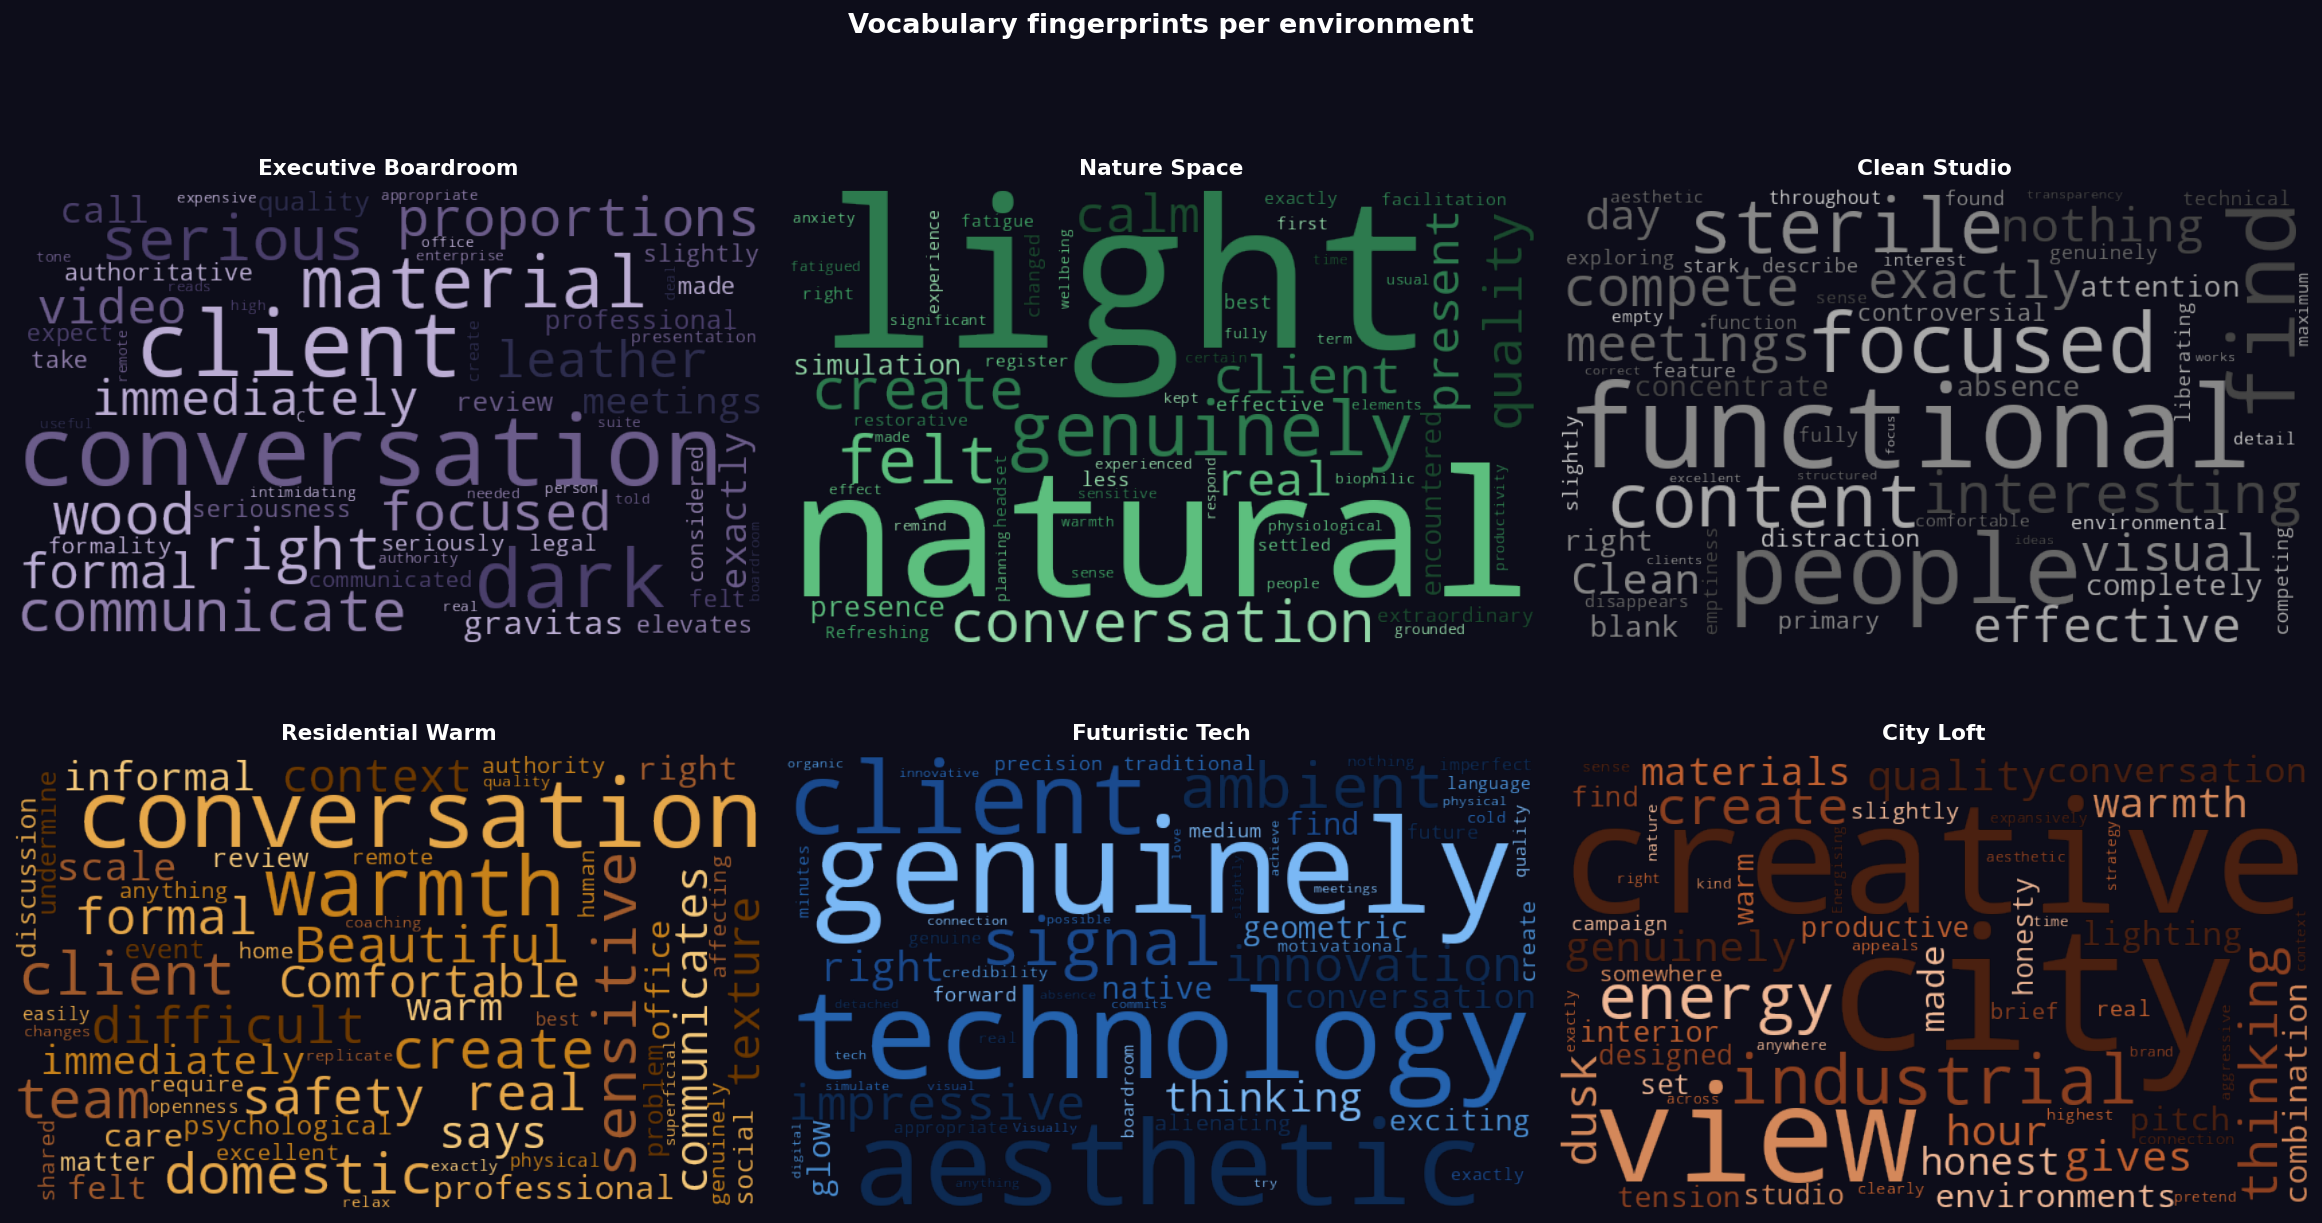

In [13]:
ENV_PALETTES = {
    'Executive Boardroom': ['#2d2d4e','#4a3f6b','#6b5c8a','#8e7daa','#bbadd4'],
    'Nature Space':        ['#1a4a2e','#2d7a4e','#3d9e62','#5dbf7e','#93d9a8'],
    'Clean Studio':        ['#444444','#666666','#888888','#aaaaaa','#cccccc'],
    'Residential Warm':    ['#6b3800','#a05a2c','#c8821a','#e6a84a','#f5c97a'],
    'Futuristic Tech':     ['#0d2a52','#1a4a8e','#2563ae','#4a8fd4','#7ab8f5'],
    'City Loft':           ['#4a2010','#8c4020','#c06030','#d4885a','#f0b896'],
}
CLOUD_STOPS = STOPWORDS | {
    'feel','feels','feeling','space','environment','vr','virtual','room','meeting',
    'think','really','just','would','could','make','makes','something','one','also',
    'bit','lot','use','used','using','session','sessions','work','working','want',
    'need','get','way','even','still','quite','rather','thing','things','much',
    'many','good','well','long','come','look','never','always','every','without',
}
env_texts = corpus.groupby('env_label')['text'].apply(' '.join).to_dict()

fig_wc, axes = plt.subplots(2, 3, figsize=(18, 10))
fig_wc.patch.set_facecolor('#0d0d1a')
fig_wc.suptitle('Vocabulary fingerprints per environment',
                color='white', fontsize=15, fontweight='bold', y=1.01)
for ax, env in zip(axes.flatten(), ENV_LABELS.values()):
    p  = ENV_PALETTES[env]
    wc = WordCloud(
        width=560, height=340, background_color=None, mode='RGBA',
        stopwords=CLOUD_STOPS, max_words=55, prefer_horizontal=0.8,
        collocations=False,
        color_func=lambda *a, **k: random.choice(p)
    ).generate(env_texts.get(env, ''))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_facecolor('#0d0d1a'); ax.axis('off')
    ax.set_title(env, color='white', fontsize=12, fontweight='bold', pad=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(p[2]); spine.set_linewidth(1.5); spine.set_visible(True)
plt.tight_layout(pad=1.2)
plt.savefig('fig_wordclouds.png', dpi=130, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
display(Image('fig_wordclouds.png'))

In [14]:
emotion_profiles = (
    corpus.groupby('environment')
    .apply(lambda g: pd.Series(
        {e: np.average(g[e], weights=g['weight']) for e in NRC_EMOTIONS}
    ))
    .reset_index()
)
emotion_profiles['env_label'] = emotion_profiles['environment'].map(ENV_LABELS)
display(emotion_profiles.set_index('env_label')[NRC_EMOTIONS].round(3))

,joy,trust,fear,surprise,sadness,disgust,anger,anticipation
env_label,,,,,,,,
City Loft,0.203,0.261,0.115,0.000,0.000,0.000,0.0,0.323
Clean Studio,0.121,0.525,0.041,0.021,0.168,0.000,0.0,0.000
Executive Boardroom,0.047,0.641,0.056,0.040,0.000,0.000,0.0,0.032
Futuristic Tech,0.375,0.150,0.023,0.062,0.105,0.000,0.0,0.075
Nature Space,0.351,0.327,0.069,0.054,0.070,0.000,0.0,0.005
Residential Warm,0.413,0.410,0.023,0.027,0.023,0.007,0.0,0.000


---
## 6. Occasion mapping (zero-shot classification)

Pre-trained NLI model classifies which **meeting occasion** each environment suits, without labelled training data — framed as: *does this text entail the space is suitable for [occasion]?*

In [15]:
OCCASION_LABELS = [
    'brainstorm or creative ideation',
    'client pitch or external presentation',
    'deep focused solo work',
    'team social event',
    'performance review or serious one on one',
    'onboarding or team welcome',
    'all hands or company wide meeting',
    'casual team check in',
]
OCCASION_KEYS = [
    'brainstorm','client_pitch','deep_work','team_social',
    'performance_review','onboarding','all_hands','casual_checkin',
]

zs_classifier = None
for model in ['facebook/bart-large-mnli','typeform/distilbert-base-uncased-mnli',
              'cross-encoder/nli-deberta-v3-small','valhalla/distilbart-mnli-12-3']:
    try:
        zs_classifier = hf_pipeline('zero-shot-classification', model=model, device=-1)
        print(f'✓ Loaded: {model}'); break
    except Exception as e:
        print(f'  ✗ {model}: {str(e)[:60]}')
if zs_classifier is None:
    print('No model loaded — using rule-based fallback.')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ Loaded: facebook/bart-large-mnli


In [16]:
def classify_occasions(text, threshold=0.15):
    if zs_classifier is None: return []
    try:
        r = zs_classifier(str(text), OCCASION_LABELS, multi_label=True)
        return [OCCASION_KEYS[OCCASION_LABELS.index(l)]
                for l, s in zip(r['labels'], r['scores']) if s >= threshold]
    except:
        return []

if zs_classifier is not None:
    surveys['occasion_labels'] = surveys['text_occasion'].apply(classify_occasions)
    print('Classification done.')
else:
    surveys['occasion_labels'] = surveys['environment'].map({
        'executive_boardroom': ['client_pitch','performance_review'],
        'nature_space':        ['deep_work','casual_checkin'],
        'clean_studio':        ['deep_work','all_hands'],
        'residential_warm':    ['team_social','onboarding'],
        'futuristic_tech':     ['brainstorm','client_pitch'],
        'city_loft':           ['brainstorm','team_social'],
    })
surveys[['response_id','environment','text_occasion','occasion_labels']].head(5)

Classification done.


,response_id,environment,text_occasion,occasion_labels
0,S001,executive_boardroom,This is exactly where I would host a quarterly business review or a client onboarding session for a major account. N...,[performance_review]
1,S002,executive_boardroom,Client presentations. Strategy sessions. Anything where I need the environment to back me up.,"[client_pitch, performance_review]"
2,S003,executive_boardroom,Contract negotiations. Client briefings. Anything where authority and seriousness are the right tone.,"[client_pitch, performance_review]"
3,S004,executive_boardroom,Client demos. Executive stakeholder meetings. Quarterly reviews.,"[client_pitch, all_hands]"
4,S005,executive_boardroom,Client pitches. Final negotiations. Anything where the deal is on the line.,"[client_pitch, all_hands, performance_review]"


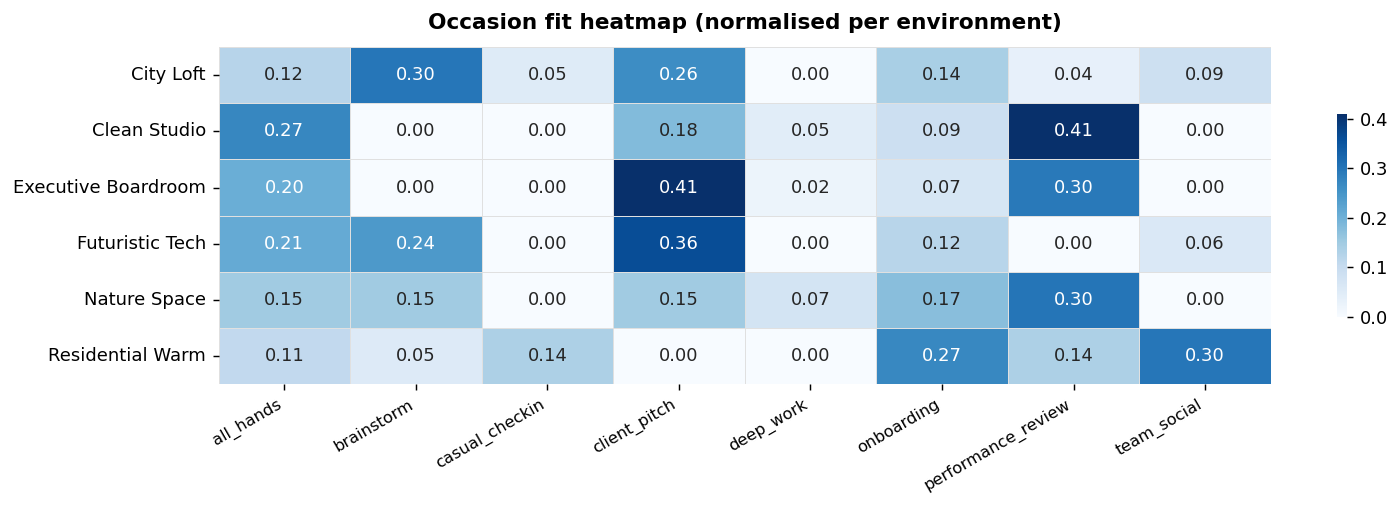

In [17]:
occ_df = pd.DataFrame([
    {'environment': row['environment'], 'occasion': occ}
    for _, row in surveys.iterrows() for occ in row['occasion_labels']
])
occ_pivot = occ_df.groupby(['environment','occasion']).size().unstack(fill_value=0)
occ_pivot.index = [ENV_LABELS.get(e,e) for e in occ_pivot.index]
occ_norm = occ_pivot.div(occ_pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(occ_norm, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.4, linecolor='#e0e0e0', ax=ax, cbar_kws={'shrink':0.6})
ax.set_title('Occasion fit heatmap (normalised per environment)', fontweight='bold', pad=10)
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_occasion_heat.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_occasion_heat.png'))

### Occasion → environment flow
Stacked bar showing the proportion of each occasion that maps to each environment.

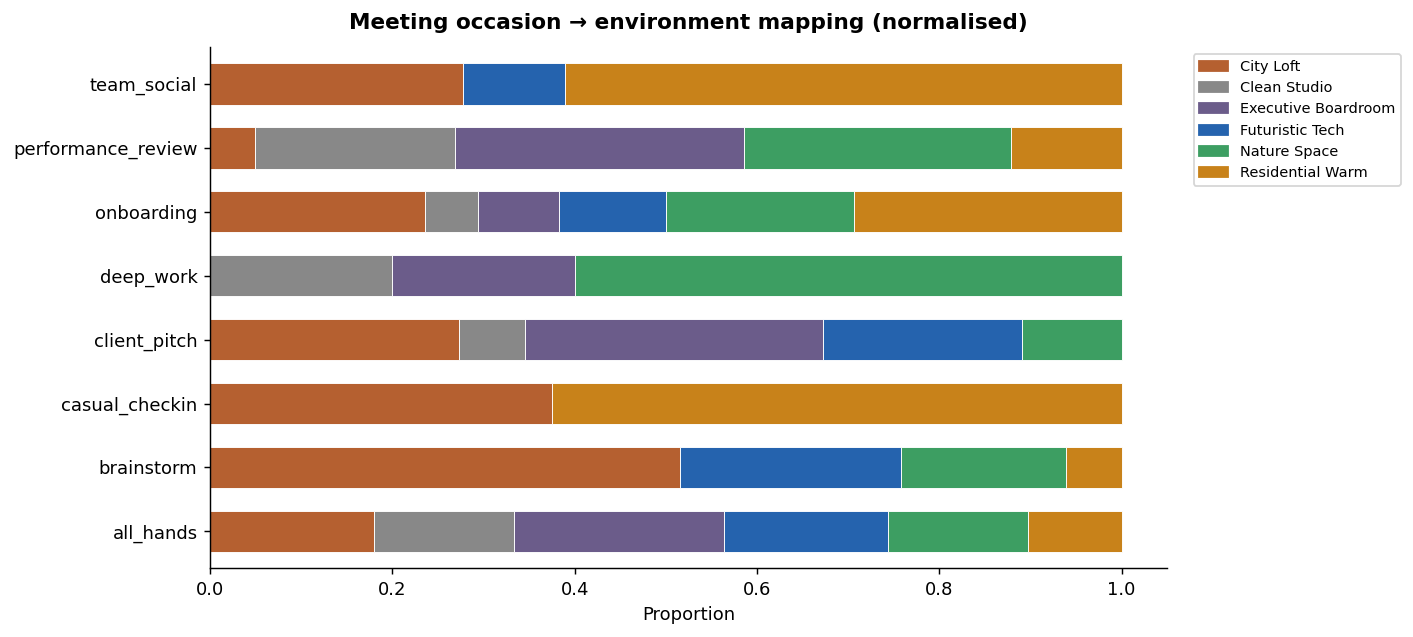

In [18]:
if surveys['occasion_labels'].apply(len).sum() == 0:
    print('Skipping — no occasion labels.')
else:
    sk_df = pd.DataFrame([
        {'occasion': occ,
         'environment': ENV_LABELS.get(row['environment'], row['environment'])}
        for _, row in surveys.iterrows() for occ in row['occasion_labels']
    ]).groupby(['occasion','environment']).size().reset_index(name='count')

    occ_env      = sk_df.pivot(index='occasion', columns='environment', values='count').fillna(0)
    occ_env_norm = occ_env.div(occ_env.sum(axis=1), axis=0)
    env_bar_cols = [ENV_COLOURS.get(e,'#888') for e in occ_env_norm.columns]

    ax = occ_env_norm.plot(kind='barh', stacked=True, figsize=(11, 5),
                           color=env_bar_cols, width=0.65,
                           edgecolor='white', linewidth=0.5)
    ax.set_title('Meeting occasion → environment mapping (normalised)',
                 fontweight='bold', pad=10)
    ax.set_xlabel('Proportion'); ax.set_ylabel('')
    handles = [mpatches.Patch(color=ENV_COLOURS.get(e,'#888'), label=e)
               for e in occ_env_norm.columns]
    ax.legend(handles=handles, bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig('fig_occasion_flow.png', dpi=130, bbox_inches='tight')
    plt.show()
    display(Image('fig_occasion_flow.png'))

---
## 7. Design attribute extraction (spaCy)

spaCy dependency parser extracts **design element → emotion** links, e.g. *"the dark wood makes me feel calm"* → `(wood, calm, material)`.

In [21]:
nlp = spacy.load('en_core_web_sm')

MATERIAL_WORDS = ['wood','leather','concrete','glass','metal','stone','fabric',
                  'marble','tile','brick','panelling','texture','surface','material']
COLOUR_WORDS   = ['dark','light','warm','cool','cold','blue','green','white','black',
                  'amber','golden','neutral','pale','tone','tones','colour','color','palette']
SPATIAL_WORDS  = ['ceiling','floor','wall','window','scale','height','volume',
                  'view','furniture','desk','chair','sofa','table','proportion']
LIGHTING_WORDS = ['light','lighting','glow','shadow','diffuse','daylight',
                  'ambient','sunlight','dusk','natural']
ALL_DESIGN     = set(MATERIAL_WORDS + COLOUR_WORDS + SPATIAL_WORDS + LIGHTING_WORDS)

def get_attr_category(w):
    w = w.lower()
    if w in LIGHTING_WORDS: return 'lighting'
    if w in MATERIAL_WORDS: return 'material'
    if w in COLOUR_WORDS:   return 'colour'
    if w in SPATIAL_WORDS:  return 'spatial'
    return 'other'

def extract_attr_pairs(text, environment):
    pairs = []
    for token in nlp(str(text)):
        if token.text.lower() in ALL_DESIGN:
            sent_score    = get_sentiment(token.sent.text)
            emotion_words = [t.text.lower() for t in token.sent
                             if t.pos_=='ADJ' and t.text.lower() in NRC_LEXICON]
            if emotion_words:
                pairs.append({
                    'environment':      environment,
                    'design_attribute': token.text.lower(),
                    'attr_category':    get_attr_category(token.text),
                    'emotion_words':    emotion_words,
                    'sentence_sentiment': round(sent_score, 3),
                })
    return pairs

all_pairs = []
for _, row in surveys.iterrows():
    all_pairs.extend(extract_attr_pairs(row['feel_text'],    row['environment']))
for _, row in interviews.iterrows():
    all_pairs.extend(extract_attr_pairs(row['segment_text'], row['environment']))

attr_df = pd.DataFrame(all_pairs)
print(f'Extracted {len(attr_df)} attribute-emotion pairs.')
attr_df.head(6)

Extracted 38 attribute-emotion pairs.


,environment,design_attribute,attr_category,emotion_words,sentence_sentiment
0,executive_boardroom,dark,colour,[serious],-0.077
1,executive_boardroom,wood,material,[serious],-0.077
2,executive_boardroom,panelling,material,[serious],-0.077
3,executive_boardroom,leather,material,[serious],-0.077
4,executive_boardroom,dark,colour,[focused],0.765
5,nature_space,natural,lighting,[extraordinary],0.361


In [22]:
attr_summary = (
    attr_df
    .groupby(['environment','design_attribute','attr_category'])
    .agg(mentions=('design_attribute','count'),
         mean_sentiment=('sentence_sentiment','mean'))
    .reset_index()
    .sort_values('mentions', ascending=False)
)
attr_summary['env_label'] = attr_summary['environment'].map(ENV_LABELS)

# alias used by bubble chart and synthesis cells
attr_agg = attr_summary.rename(columns={'design_attribute':'chunk','attr_category':'category'})
attr_agg['env_label'] = attr_agg['environment'].map(ENV_LABELS)

display(
    attr_summary.groupby('env_label').head(2)
    [['env_label','design_attribute','attr_category','mentions','mean_sentiment']].round(3)
)

,env_label,design_attribute,attr_category,mentions,mean_sentiment
14,Nature Space,light,lighting,9,0.457
15,Nature Space,natural,lighting,5,0.586
3,City Loft,view,spatial,3,0.195
4,City Loft,warm,colour,3,0.694
16,Residential Warm,scale,spatial,2,0.489
17,Residential Warm,warm,colour,2,0.481
6,Executive Boardroom,dark,colour,2,0.344
9,Executive Boardroom,panelling,material,1,-0.077
5,Clean Studio,cold,colour,1,0.743
13,Futuristic Tech,glow,lighting,1,0.832


---
## 8. Topic modelling (TF-IDF + NMF)

Discovers 8 latent themes across the corpus without labelled examples. TF-IDF vectors → NMF factorisation → top words per component.

In [23]:
vectorizer   = TfidfVectorizer(max_features=300, ngram_range=(1,2),
                               stop_words='english', min_df=2)
tfidf_matrix = vectorizer.fit_transform(corpus['text'].tolist())
feature_names = vectorizer.get_feature_names_out()

nmf          = NMF(n_components=8, random_state=42, max_iter=400)
topic_matrix = nmf.fit_transform(tfidf_matrix)

print('Discovered topics (top 8 words each):\n')
for i, v in enumerate(nmf.components_):
    top = ', '.join(feature_names[j] for j in v.argsort()[:-9:-1])
    print(f'  Topic {i+1}: {top}')

Discovered topics (top 8 words each):

  Topic 1: space, conversation, forgot, formal, vr, real, feel, environment
  Topic 2: light, natural, natural light, vr, felt, genuinely, long, present
  Topic 3: creative, city, energy, city view, view, industrial, creative energy, thinking
  Topic 4: use, day, meetings, sensitive, client, conversation, strategic, sensitive conversations
  Topic 5: conversations, environment, clients, technology, aesthetic, right, quality, warmth
  Topic 6: meeting, functional, people, sterile, environment, feeling, focused, slightly
  Topic 7: dark, like, dark wood, wood, leather, materials, feel like, proportions
  Topic 8: work, team, perfect, real, focus, love, beautiful, review


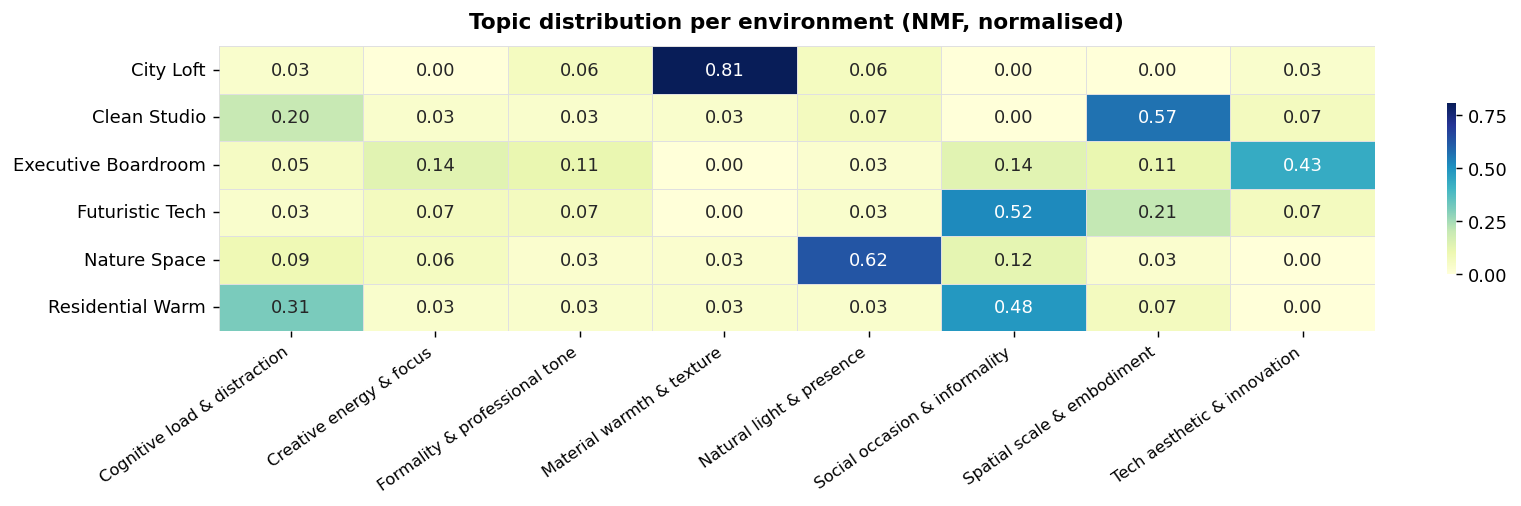

In [24]:
TOPIC_LABELS = [
    'Formality & professional tone',
    'Natural light & presence',
    'Material warmth & texture',
    'Creative energy & focus',
    'Social occasion & informality',
    'Spatial scale & embodiment',
    'Tech aesthetic & innovation',
    'Cognitive load & distraction',
]
corpus['topic_id']    = topic_matrix.argmax(axis=1)
corpus['topic_label'] = corpus['topic_id'].map(lambda i: TOPIC_LABELS[i])

topic_norm = (
    corpus.groupby(['env_label','topic_label']).size().unstack(fill_value=0)
    .pipe(lambda df: df.div(df.sum(axis=1), axis=0))
)

# ── heatmap ──
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(topic_norm, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.4, linecolor='#e0e0e0', ax=ax, cbar_kws={'shrink':0.6})
ax.set_title('Topic distribution per environment (NMF, normalised)', fontweight='bold', pad=10)
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_topic_heat.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_topic_heat.png'))

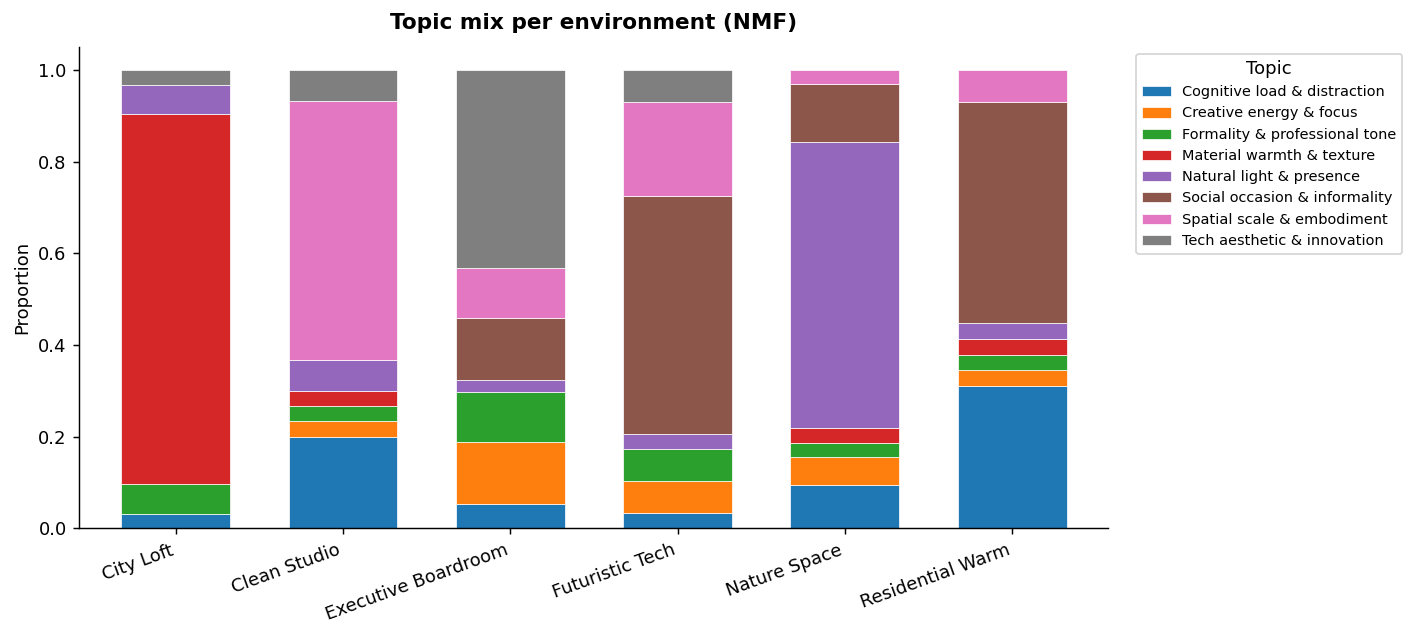

In [25]:
# ── stacked bar — topic mix per environment ──
topic_cols = [plt.cm.tab10(i) for i in range(len(TOPIC_LABELS))]
ax = topic_norm.plot(kind='bar', stacked=True, figsize=(11, 5),
                     color=topic_cols, width=0.65,
                     edgecolor='white', linewidth=0.4)
ax.set_title('Topic mix per environment (NMF)', fontweight='bold', pad=10)
ax.set_xlabel(''); ax.set_ylabel('Proportion')
ax.legend(title='Topic', bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig_topic_bar.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_topic_bar.png'))

---
## 9. Emotion profiles per environment

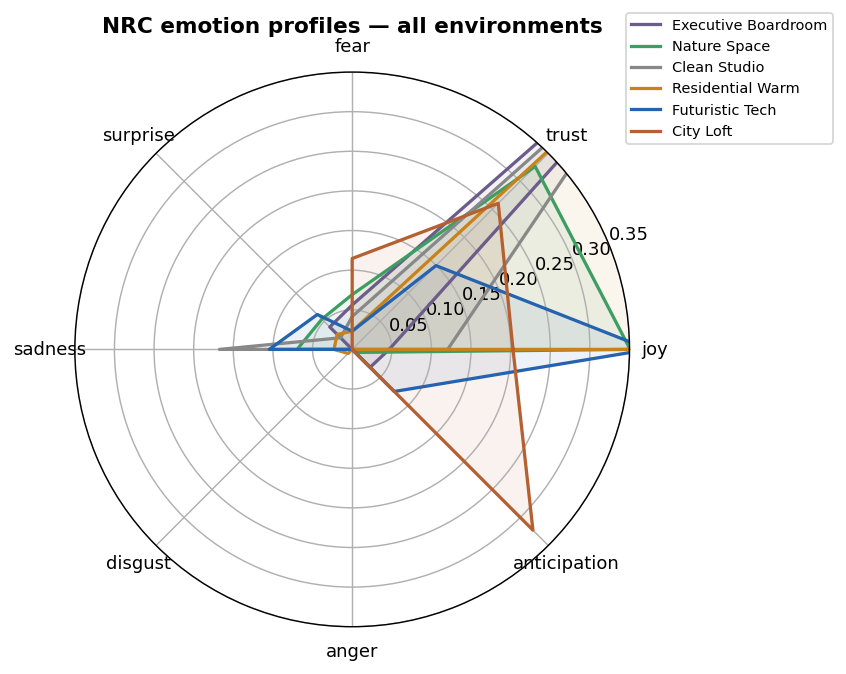

In [26]:
# ── overlaid radar ──
ENVS_ORDERED = list(ENV_LABELS.values())
COLOURS      = ['#6b5c8a','#3d9e62','#888888','#c8821a','#2563ae','#b56030']
N      = len(NRC_EMOTIONS)
angles = [n / float(N) * 2 * math.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for env, colour in zip(ENVS_ORDERED, COLOURS):
    row = emotion_profiles[emotion_profiles['env_label']==env]
    if len(row) == 0: continue
    vals = [row[e].values[0] for e in NRC_EMOTIONS] + [row[NRC_EMOTIONS[0]].values[0]]
    ax.plot(angles, vals, color=colour, linewidth=1.8, label=env)
    ax.fill(angles, vals, color=colour, alpha=0.08)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(NRC_EMOTIONS, fontsize=10)
ax.set_ylim(0, 0.35)
ax.set_title('NRC emotion profiles — all environments', fontweight='bold', pad=22)
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.12), fontsize=8)
plt.tight_layout()
plt.savefig('fig_radar_all.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_radar_all.png'))

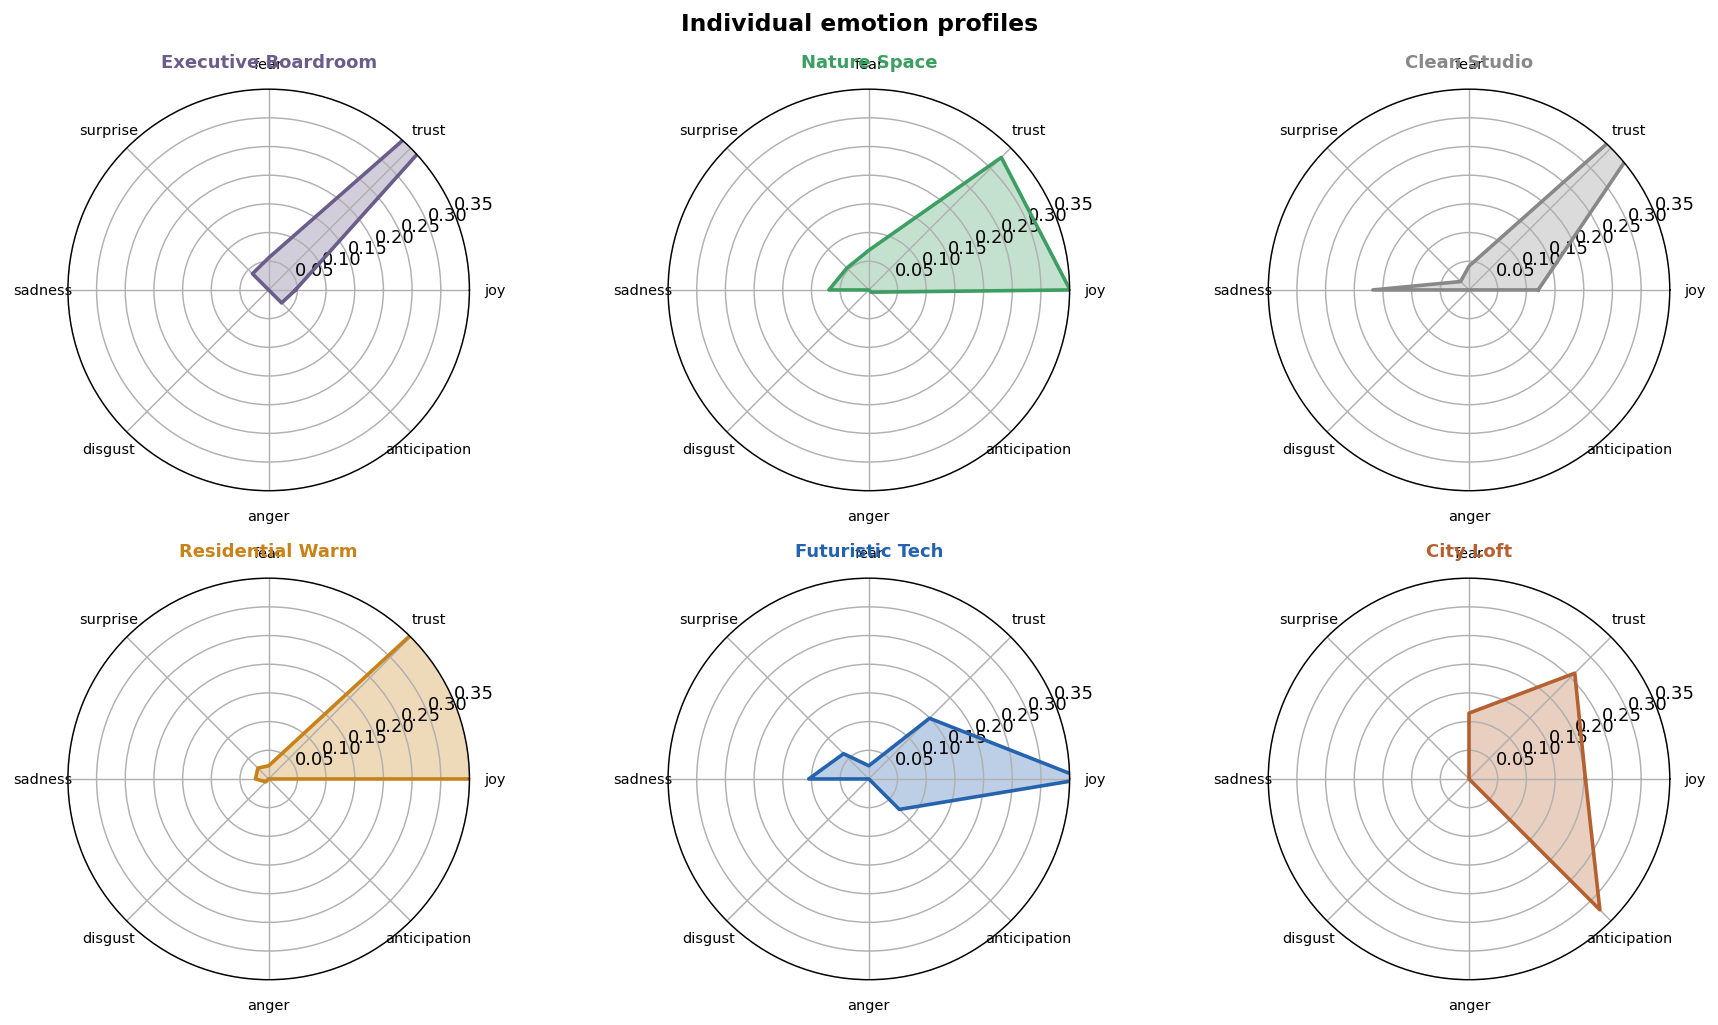

In [27]:
# ── individual radars 2×3 ──
fig, axes = plt.subplots(2, 3, figsize=(14, 8), subplot_kw=dict(polar=True))
for ax, env, colour in zip(axes.flatten(), ENVS_ORDERED, COLOURS):
    row = emotion_profiles[emotion_profiles['env_label']==env]
    if len(row) == 0:
        ax.set_visible(False); continue
    vals = [row[e].values[0] for e in NRC_EMOTIONS] + [row[NRC_EMOTIONS[0]].values[0]]
    ax.plot(angles, vals, color=colour, linewidth=2)
    ax.fill(angles, vals, color=colour, alpha=0.30)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(NRC_EMOTIONS, fontsize=8)
    ax.set_ylim(0, 0.35)
    ax.set_title(env, fontweight='bold', pad=12, fontsize=10, color=colour)
fig.suptitle('Individual emotion profiles', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_radar_individual.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_radar_individual.png'))

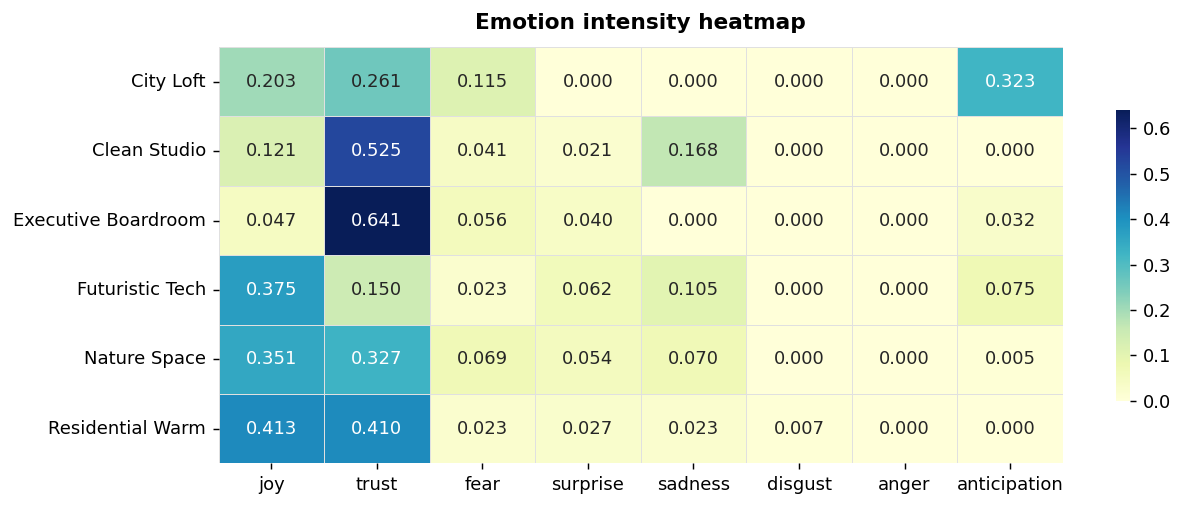

In [28]:
# ── emotion intensity heatmap ──
heat_data = emotion_profiles.set_index('env_label')[NRC_EMOTIONS]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.4, linecolor='#e0e0e0', ax=ax, cbar_kws={'shrink':0.7})
ax.set_title('Emotion intensity heatmap', fontweight='bold', pad=10)
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_emotion_heat.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_emotion_heat.png'))

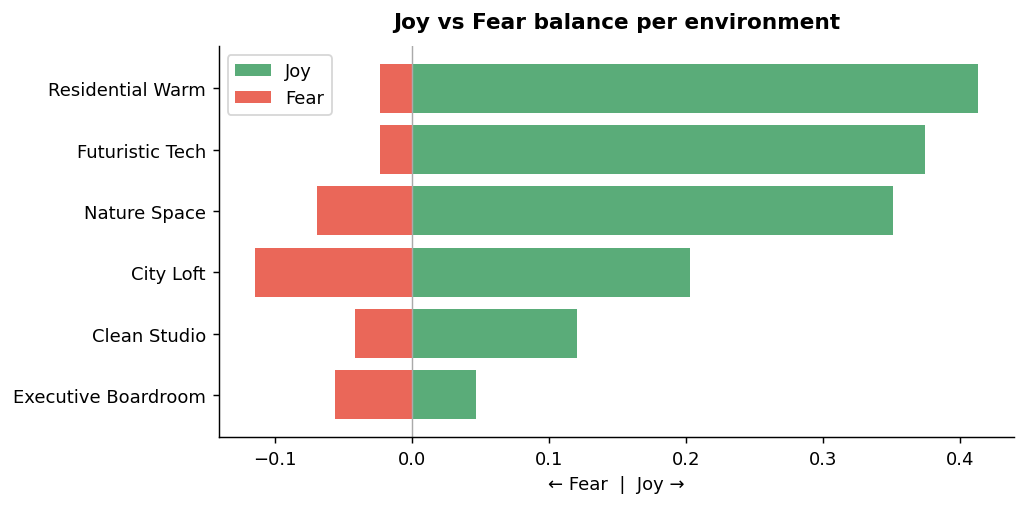

In [29]:
# ── Joy vs Fear diverging bar ──
ep_plot     = emotion_profiles.set_index('env_label')[['joy','fear']].copy()
envs_sorted = ep_plot.sort_values('joy').index.tolist()
y           = range(len(envs_sorted))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(list(y),  ep_plot.loc[envs_sorted,'joy'],          color='#3d9e62', label='Joy',  alpha=0.85)
ax.barh(list(y), -ep_plot.loc[envs_sorted,'fear'],         color='#e74c3c', label='Fear', alpha=0.85)
ax.axvline(0, color='#aaaaaa', linewidth=0.8)
ax.set_yticks(list(y)); ax.set_yticklabels(envs_sorted)
ax.set_xlabel('← Fear  |  Joy →')
ax.set_title('Joy vs Fear balance per environment', fontweight='bold', pad=10)
ax.legend()
plt.tight_layout()
plt.savefig('fig_joy_fear.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_joy_fear.png'))

---
## 10. Tech vs non-tech customer split

**Finding:** Technology-sector customers respond very differently to Futuristic Tech. This split is invisible in aggregate scores — only appears when filtered by `customer_industry`.

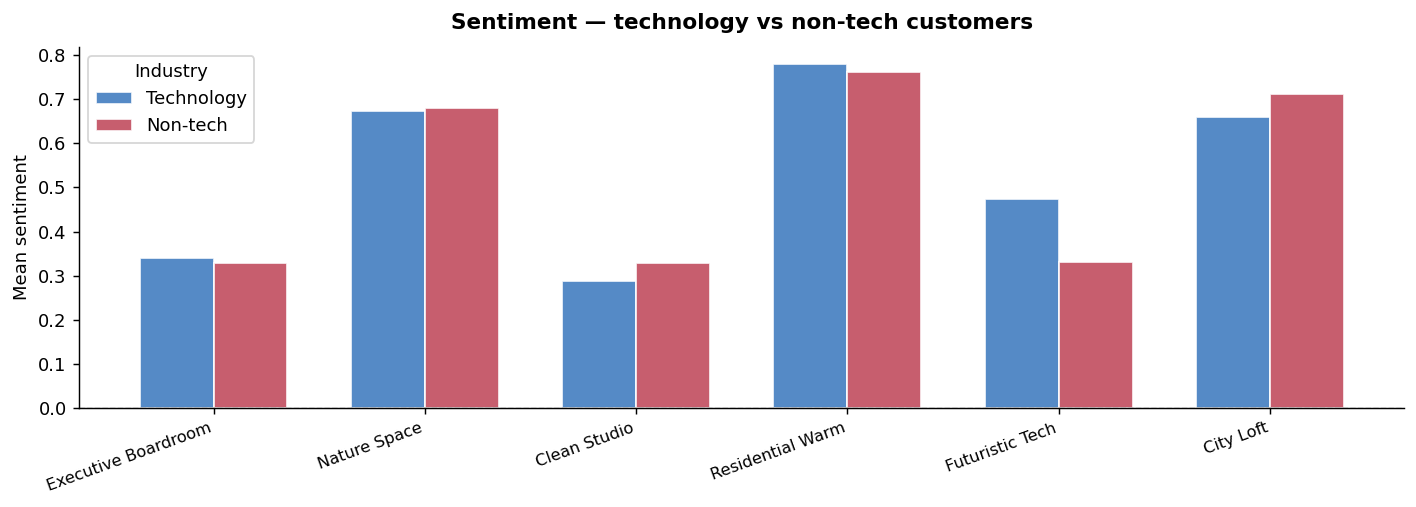


Futuristic Tech sentiment split:
industry_class  sentiment_score
      Non-tech         0.330125
    Technology         0.473045
Gap: 0.143


In [30]:
customer_corpus = corpus[corpus['participant_type']=='customer'].copy()
customer_corpus['industry_class'] = customer_corpus['group'].apply(
    lambda g: 'Technology' if g=='technology' else 'Non-tech'
)

role_sent = customer_corpus.groupby(['env_label','industry_class'])['sentiment_score'].mean().reset_index()
IND_C     = {'Technology':'#3d7abf', 'Non-tech':'#c0485a'}
groups    = ['Technology','Non-tech']
x, w      = np.arange(len(envs)), 0.35

fig, ax = plt.subplots(figsize=(11, 4))
for i, grp in enumerate(groups):
    d    = role_sent[role_sent['industry_class']==grp].set_index('env_label')['sentiment_score']
    vals = [d.get(e, 0) for e in envs]
    ax.bar(x + i*w, vals, w, label=grp, color=IND_C[grp], alpha=0.88, edgecolor='white')
ax.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
ax.set_xticks(x + w/2)
ax.set_xticklabels(envs, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Mean sentiment')
ax.set_title('Sentiment — technology vs non-tech customers', fontweight='bold', pad=10)
ax.legend(title='Industry')
plt.tight_layout()
plt.savefig('fig_tech_split.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_tech_split.png'))

tech_split = role_sent[role_sent['env_label']=='Futuristic Tech']
print('\nFuturistic Tech sentiment split:')
print(tech_split[['industry_class','sentiment_score']].to_string(index=False))
if len(tech_split)==2:
    print(f'Gap: {tech_split["sentiment_score"].max()-tech_split["sentiment_score"].min():.3f}')

---
## 11. Natural light signal

**Finding:** Natural light was the only design attribute where all three source channels agreed — same direction, same intensity, same occasion mapping (positive across all session types).

Documents mentioning natural light: 25 of 188

By environment:
environment
nature_space           21
city_loft               2
executive_boardroom     1
clean_studio            1

Mean sentiment — light vs non-light docs:
mentions_light
False    0.404
True     0.641

Cross-source agreement:
source
interview    0.614
sticky       0.466
survey       0.689
All three sources positive? True


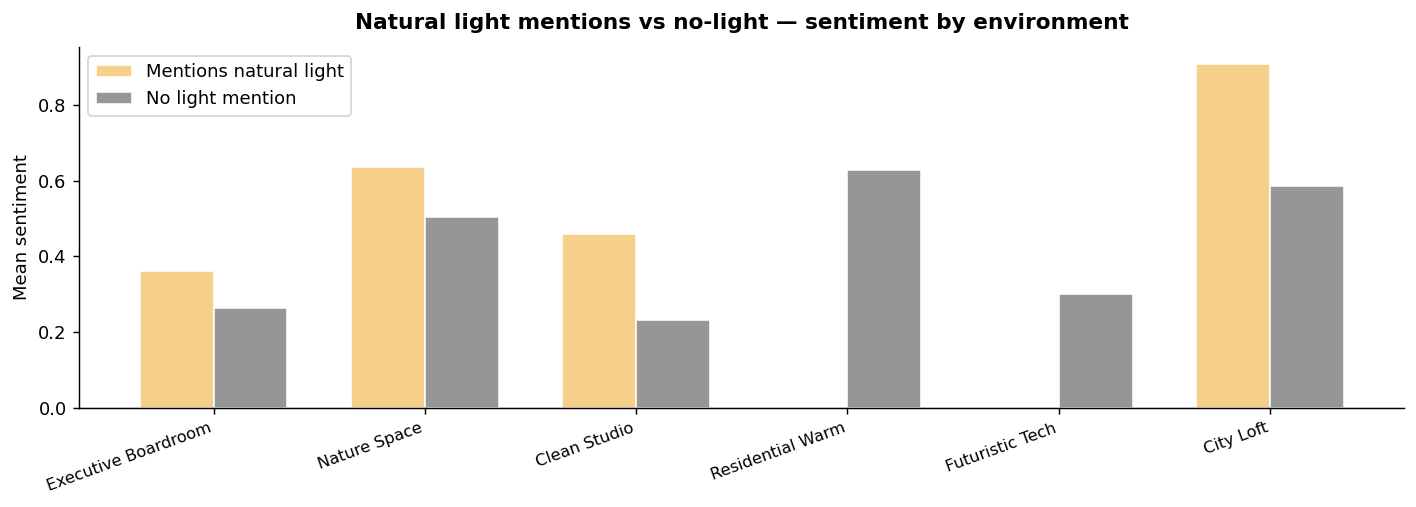

In [31]:
LIGHT_TERMS = ['natural light','daylight','natural lighting',
               'light simulation','sunlight','the light','natural']
corpus['mentions_light'] = corpus['text'].apply(
    lambda t: any(term in str(t).lower() for term in LIGHT_TERMS)
)

light_docs = corpus[corpus['mentions_light']]
print(f'Documents mentioning natural light: {len(light_docs)} of {len(corpus)}')
print('\nBy environment:')
print(light_docs['environment'].value_counts().to_string())
print('\nMean sentiment — light vs non-light docs:')
print(corpus.groupby('mentions_light')['sentiment_score'].mean().round(3).to_string())
print('\nCross-source agreement:')
print(light_docs.groupby('source')['sentiment_score'].mean().round(3).to_string())
print('All three sources positive?',
      (light_docs.groupby('source')['sentiment_score'].mean() > 0).all())

light_sent = corpus.groupby(['env_label','mentions_light'])['sentiment_score'].mean().reset_index()
x, w = np.arange(len(envs)), 0.35

fig, ax = plt.subplots(figsize=(11, 4))
for i, (flag, label, colour) in enumerate([
    (True,  'Mentions natural light', '#f5c97a'),
    (False, 'No light mention',       '#888888')
]):
    d    = light_sent[light_sent['mentions_light']==flag].set_index('env_label')['sentiment_score']
    vals = [d.get(e, 0) for e in envs]
    ax.bar(x + i*w, vals, w, label=label, color=colour, alpha=0.88, edgecolor='white')
ax.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
ax.set_xticks(x + w/2)
ax.set_xticklabels(envs, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Mean sentiment')
ax.set_title('Natural light mentions vs no-light — sentiment by environment',
             fontweight='bold', pad=10)
ax.legend()
plt.tight_layout()
plt.savefig('fig_light.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_light.png'))

---
## 12. Source triangulation & confidence

High-confidence findings = all three sources agree on sentiment direction.

In [32]:
source_pivot = corpus.groupby(['environment','source'])['sentiment_score'].mean().unstack()

def agreement(row):
    d = [1 if v>0.05 else (-1 if v<-0.05 else 0) for v in row if not pd.isna(v)]
    d = [x for x in d if x != 0]
    return 'neutral' if not d else ('full agreement' if len(set(d))==1 else 'split signal')

source_pivot['agreement'] = source_pivot.apply(agreement, axis=1)
source_pivot.index = [ENV_LABELS.get(e,e) for e in source_pivot.index]
print('Cross-source agreement:')
display(source_pivot.round(3))

Cross-source agreement:


source,interview,sticky,survey,agreement
City Loft,0.888,0.422,0.652,full agreement
Clean Studio,0.052,0.100,0.357,full agreement
Executive Boardroom,0.312,0.092,0.334,full agreement
Futuristic Tech,0.685,0.087,0.362,full agreement
Nature Space,0.512,0.402,0.704,full agreement
Residential Warm,0.452,0.368,0.825,full agreement


,Environment,N,Wtd Sentiment,Std Dev,confidence
2,Executive Boardroom,37,0.302,0.424,0.821
4,Nature Space,32,0.636,0.343,0.793
0,City Loft,31,0.660,0.350,0.780
5,Residential Warm,29,0.696,0.307,0.773
3,Futuristic Tech,29,0.364,0.414,0.738
1,Clean Studio,30,0.274,0.474,0.731


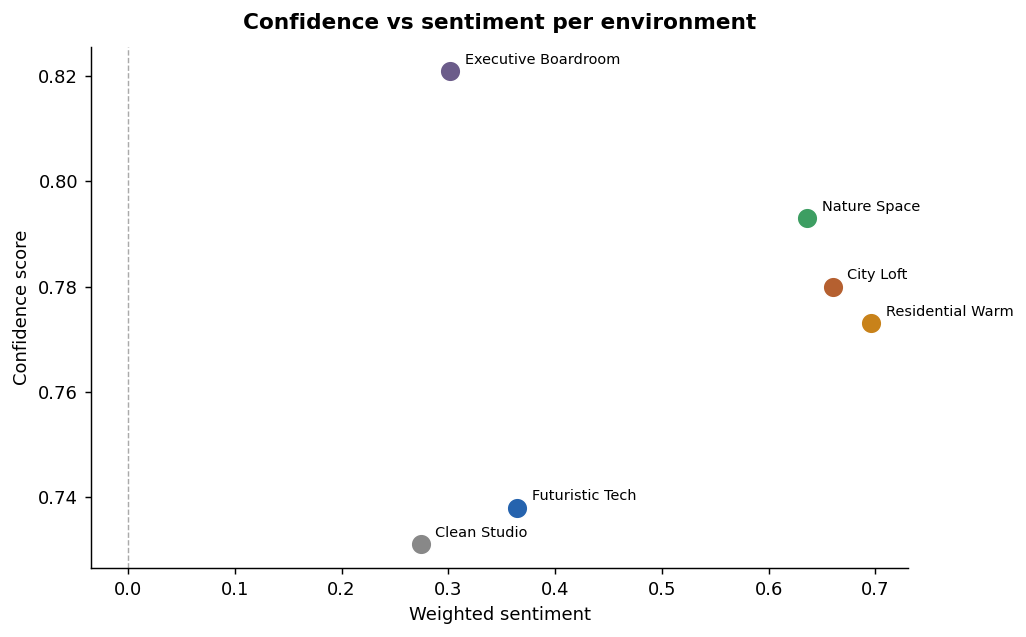

In [33]:
conf = corpus.groupby('environment').agg(
    n_docs            = ('sentiment_score', 'count'),
    mean_sentiment    = ('sentiment_score', 'mean'),
    std_sentiment     = ('sentiment_score', 'std'),
    weighted_sentiment= ('sentiment_score',
        lambda x: np.average(x, weights=corpus.loc[x.index,'weight']))
).reset_index()
conf['confidence'] = (
    (1/(1+conf['std_sentiment']))*0.6
    + (conf['n_docs']/conf['n_docs'].max())*0.4
).round(3)
conf['env_label'] = conf['environment'].map(ENV_LABELS)
conf = conf.sort_values('confidence', ascending=False)

display(
    conf[['env_label','n_docs','weighted_sentiment','std_sentiment','confidence']]
    .rename(columns={'env_label':'Environment','n_docs':'N',
                     'weighted_sentiment':'Wtd Sentiment','std_sentiment':'Std Dev'})
    .round(3)
)

# Confidence vs sentiment scatter
fig, ax = plt.subplots(figsize=(8, 5))
for _, row in conf.iterrows():
    c = ENV_COLOURS.get(row['env_label'], '#888')
    ax.scatter(row['weighted_sentiment'], row['confidence'],
               color=c, s=130, zorder=3, edgecolors='white', linewidths=0.8)
    ax.annotate(row['env_label'],
                (row['weighted_sentiment'], row['confidence']),
                textcoords='offset points', xytext=(8, 4), fontsize=8)
ax.axvline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
ax.set_xlabel('Weighted sentiment')
ax.set_ylabel('Confidence score')
ax.set_title('Confidence vs sentiment per environment', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig_confidence.png', dpi=130, bbox_inches='tight')
plt.show()
display(Image('fig_confidence.png'))

---
## 13. Final synthesis table

Main deliverable for the 3D arts team — links design attributes, emotions, occasion fit, and confidence in a single structured table.

In [34]:
ep = emotion_profiles.copy()
ep['primary_emotion'] = ep[NRC_EMOTIONS].idxmax(axis=1)

top_occasion = occ_norm.idxmax(axis=1).reset_index()
top_occasion.columns = ['env_label','top_occasion']
top_occasion['environment'] = top_occasion['env_label'].map(
    {v: k for k, v in ENV_LABELS.items()}
)

top_attrs = attr_summary.sort_values('mentions', ascending=False).groupby('environment').head(2)

synthesis = (
    top_attrs
    .merge(conf[['environment','confidence','weighted_sentiment']], on='environment')
    .merge(ep[['environment','primary_emotion']], on='environment')
    .merge(top_occasion[['environment','top_occasion']], on='environment', how='left')
)
synthesis['env_label'] = synthesis['environment'].map(ENV_LABELS)
synthesis['valence']   = synthesis['weighted_sentiment'].apply(
    lambda v: 'Strongly positive' if v>0.4
    else ('Positive' if v>0.05 else ('Negative' if v<-0.05 else 'Mixed'))
)

final = (
    synthesis[['env_label','design_attribute','attr_category','primary_emotion',
               'valence','top_occasion','mentions','confidence']]
    .sort_values(['primary_emotion','mentions'], ascending=[True,False])
    .rename(columns={
        'env_label':        'Environment',
        'design_attribute': 'Design Attribute',
        'attr_category':    'Category',
        'primary_emotion':  'Primary Emotion',
        'valence':          'Valence',
        'top_occasion':     'Top Occasion',
        'mentions':         'Attribute Mentions',
        'confidence':       'Confidence',
    })
)

print('FINAL SYNTHESIS — Emotion-Attribute Mapping for 3D Arts Team')
print('Sorted by primary emotion (A→Z), then attribute mention count (high→low)')
display(final)
final.to_csv('synthesis_table.csv', index=False)
print('\nsynthesis_table.csv saved.')

FINAL SYNTHESIS — Emotion-Attribute Mapping for 3D Arts Team
Sorted by primary emotion (A→Z), then attribute mention count (high→low)


,Environment,Design Attribute,Category,Primary Emotion,Valence,Top Occasion,Attribute Mentions,Confidence
2,City Loft,view,spatial,anticipation,Strongly positive,brainstorm,3,0.780
3,City Loft,warm,colour,anticipation,Strongly positive,brainstorm,3,0.780
0,Nature Space,light,lighting,joy,Strongly positive,performance_review,9,0.793
1,Nature Space,natural,lighting,joy,Strongly positive,performance_review,5,0.793
4,Residential Warm,scale,spatial,joy,Strongly positive,team_social,2,0.773
5,Residential Warm,warm,colour,joy,Strongly positive,team_social,2,0.773
9,Futuristic Tech,glow,lighting,joy,Positive,client_pitch,1,0.738
10,Futuristic Tech,cold,colour,joy,Positive,client_pitch,1,0.738
6,Executive Boardroom,dark,colour,trust,Positive,client_pitch,2,0.821
7,Executive Boardroom,panelling,material,trust,Positive,client_pitch,1,0.821



synthesis_table.csv saved.


In [35]:
import json, pathlib

path = pathlib.Path('/content/drive/MyDrive/Data Science/7. NLP - META/vr_workrooms_nlp.ipynb')
nb = json.loads(path.read_text())
nb.get('metadata', {}).pop('widgets', None)
path.write_text(json.dumps(nb, indent=1))
print('Done')

Done
